# Maternal Digital Twin — GDM Prediction Module

## 1. Project Introduction

**Module purpose:** This notebook implements the **Gestational Diabetes Mellitus (GDM) prediction module**
of the *Maternal Digital Twin* capstone project. It is one of four modules built by a 4-person team; this
module focuses **only** on predicting GDM risk from early-pregnancy clinical and demographic features.

**Dataset:** The data used here is **entirely synthetic**. It was generated for academic/prototyping
purposes and **does not represent real patients or real clinical outcomes**. No conclusions about real-world
GDM epidemiology, causation, or clinical practice should be drawn from this notebook.

**Target variable:** `gdm_outcome`
- `0` = No GDM
- `1` = GDM

**What this notebook is:** A **student decision-support prototype** demonstrating an end-to-end ML
pipeline (EDA → preprocessing → modeling → evaluation → explainability → persistence).

**What this notebook is NOT:**
- It is **not** a diagnostic tool.
- It is **not** validated on real patients.
- It should **never** be used to make actual clinical decisions.
- Any "prediction" produced at the end is a **model output for demonstration purposes only**.


## 2. Import Libraries

This notebook needs `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `xgboost`, `shap`, and
`joblib`. If `xgboost` or `shap` are not installed in your environment, run the following in a terminal
(or a notebook cell prefixed with `!`) and then restart the kernel:

```
pip install xgboost shap
```

The code cell below imports everything needed and uses flags (`XGBOOST_AVAILABLE`, `SHAP_AVAILABLE`) so
that the rest of the notebook degrades gracefully if either package is missing, instead of crashing.


In [50]:
# --- Core libraries ---
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay
)

# --- joblib for saving the final pipeline ---
import joblib

# --- Optional: XGBoost ---
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not installed. Run `pip install xgboost` and restart the kernel to enable it.")

# --- Optional: SHAP ---
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP is not installed. Run `pip install shap` and restart the kernel to enable SHAP analysis.")

warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"SHAP available: {SHAP_AVAILABLE}")


XGBoost is not installed. Run `pip install xgboost` and restart the kernel to enable it.
Libraries imported successfully.
XGBoost available: False
SHAP available: True


## 3. Load Data

The dataset is expected at `data/gdm_dataset.csv`, relative to the project root (i.e., run this notebook
from the project's root folder, or adjust `DATA_PATH` below if needed). The raw CSV is **never modified**
by this notebook.


In [51]:
DATA_PATH = r"D:\Capstone-AI-Project\data\gdm_synthetic_data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Could not find dataset at: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 17)


In [52]:
# Shape
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (10000, 17)


In [53]:
# First 5 rows
df.head()


,patient_id,age,pre_pregnancy_bmi,ethnicity,family_history_dm,previous_gdm,pcos,previous_macrosomia,booking_gestational_age,early_rbs_mgdl,early_ppbs_mgdl,early_hba1c_percent,early_ogtt_performed,early_ogtt_fasting_mgdl,early_ogtt_1h_mgdl,early_ogtt_2h_mgdl,gdm_outcome
0,P0001,30.5,25.4,Caucasian,0,0,0,0,10.6,117.5,122.5,5.26,0,NaN,NaN,NaN,0
1,P0002,32.8,24.3,Asian,0,0,0,0,8.5,101.0,144.9,5.27,0,NaN,NaN,NaN,1
2,P0003,27.9,19.8,Caucasian,0,1,0,0,15.6,127.4,147.5,6.10,0,NaN,NaN,NaN,1
3,P0004,25.3,19.5,Caucasian,1,0,1,0,10.3,126.5,163.7,5.47,0,NaN,NaN,NaN,1
4,P0005,22.5,19.2,Caucasian,0,0,1,0,11.9,108.4,156.7,5.39,0,NaN,NaN,NaN,0


In [54]:
# Column names
print("Columns:")
for c in df.columns:
    print(" -", c)


Columns:
 - patient_id
 - age
 - pre_pregnancy_bmi
 - ethnicity
 - family_history_dm
 - previous_gdm
 - pcos
 - previous_macrosomia
 - booking_gestational_age
 - early_rbs_mgdl
 - early_ppbs_mgdl
 - early_hba1c_percent
 - early_ogtt_performed
 - early_ogtt_fasting_mgdl
 - early_ogtt_1h_mgdl
 - early_ogtt_2h_mgdl
 - gdm_outcome


In [55]:
# Info: dtypes, non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               10000 non-null  str    
 1   age                      10000 non-null  float64
 2   pre_pregnancy_bmi        10000 non-null  float64
 3   ethnicity                10000 non-null  str    
 4   family_history_dm        10000 non-null  int64  
 5   previous_gdm             10000 non-null  int64  
 6   pcos                     10000 non-null  int64  
 7   previous_macrosomia      10000 non-null  int64  
 8   booking_gestational_age  10000 non-null  float64
 9   early_rbs_mgdl           10000 non-null  float64
 10  early_ppbs_mgdl          10000 non-null  float64
 11  early_hba1c_percent      10000 non-null  float64
 12  early_ogtt_performed     10000 non-null  int64  
 13  early_ogtt_fasting_mgdl  2952 non-null   float64
 14  early_ogtt_1h_mgdl       2952 non-

In [56]:
# Descriptive statistics (numeric columns)
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,10000.0,28.034020,4.858715,18.0,24.675,28.00,31.400,45.0
pre_pregnancy_bmi,10000.0,24.677420,4.051290,16.0,21.900,24.60,27.400,42.4
family_history_dm,10000.0,0.251700,0.434011,0.0,0.000,0.00,1.000,1.0
previous_gdm,10000.0,0.113200,0.316853,0.0,0.000,0.00,0.000,1.0
pcos,10000.0,0.152900,0.359909,0.0,0.000,0.00,0.000,1.0
previous_macrosomia,10000.0,0.097900,0.297194,0.0,0.000,0.00,0.000,1.0
booking_gestational_age,10000.0,10.037310,1.968022,6.0,8.600,10.00,11.400,16.0
early_rbs_mgdl,10000.0,109.095100,18.848610,70.0,96.000,108.50,121.700,200.0
early_ppbs_mgdl,10000.0,142.539400,24.155854,90.0,125.700,142.20,158.600,245.1
early_hba1c_percent,10000.0,5.723652,0.583096,4.0,5.320,5.70,6.100,8.0


## 4. Exploratory Data Analysis (EDA)

This section performs a concise but complete EDA: dimensions, dtypes, missing values, duplicates, target
distribution, feature distributions, outlier inspection, GDM-outcome comparisons, correlations, and a
dedicated look at OGTT missingness.


### 4A. Dataset dimensions

In [57]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Rows: 10,000
Columns: 17


### 4B. Data types

In [58]:
dtype_summary = df.dtypes.astype(str).value_counts()
print(dtype_summary)
df.dtypes


float64    9
int64      6
str        2
Name: count, dtype: int64


patient_id                     str
age                        float64
pre_pregnancy_bmi          float64
ethnicity                      str
family_history_dm            int64
previous_gdm                 int64
pcos                         int64
previous_macrosomia          int64
booking_gestational_age    float64
early_rbs_mgdl             float64
early_ppbs_mgdl            float64
early_hba1c_percent        float64
early_ogtt_performed         int64
early_ogtt_fasting_mgdl    float64
early_ogtt_1h_mgdl         float64
early_ogtt_2h_mgdl         float64
gdm_outcome                  int64
dtype: object

### 4C. Missing values

In [59]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)
print("Columns with missing values:")
missing_summary


Columns with missing values:


,missing_count,missing_pct
early_ogtt_fasting_mgdl,7048,70.48
early_ogtt_1h_mgdl,7048,70.48
early_ogtt_2h_mgdl,7048,70.48


### 4D. Duplicate rows

In [60]:
n_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {n_duplicates}")


Number of fully duplicated rows: 0


### 4E. Target distribution

gdm_outcome
0    3494
1    6506
Name: count, dtype: int64


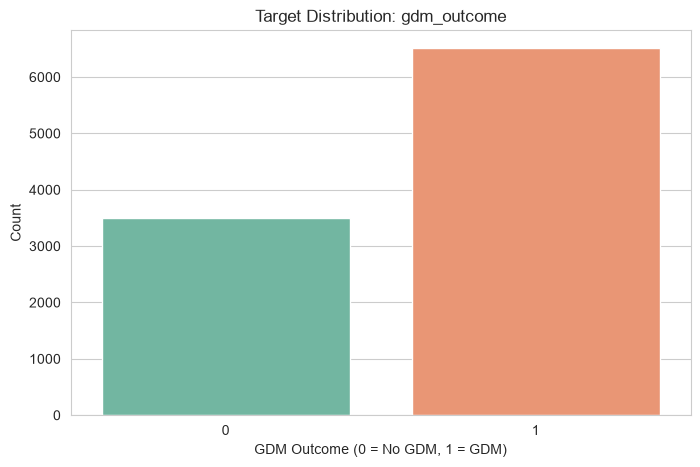

In [61]:
target_counts = df["gdm_outcome"].value_counts().sort_index()
print(target_counts)

plt.figure()
sns.countplot(x="gdm_outcome", data=df, hue="gdm_outcome", palette="Set2", legend=False)
plt.title("Target Distribution: gdm_outcome")
plt.xlabel("GDM Outcome (0 = No GDM, 1 = GDM)")
plt.ylabel("Count")
plt.show()


### 4F. Class percentages

In [62]:
class_pct = (df["gdm_outcome"].value_counts(normalize=True) * 100).round(2).sort_index()
print("Class percentages:")
print(class_pct)
print(f"\nGDM prevalence in this dataset: {class_pct.get(1, 0)}% "
      f"(note: this is notably higher than typical real-world GDM prevalence, "
      f"a characteristic of this synthetic dataset).")


Class percentages:
gdm_outcome
0    34.94
1    65.06
Name: proportion, dtype: float64

GDM prevalence in this dataset: 65.06% (note: this is notably higher than typical real-world GDM prevalence, a characteristic of this synthetic dataset).


### 4G. Numerical feature distributions

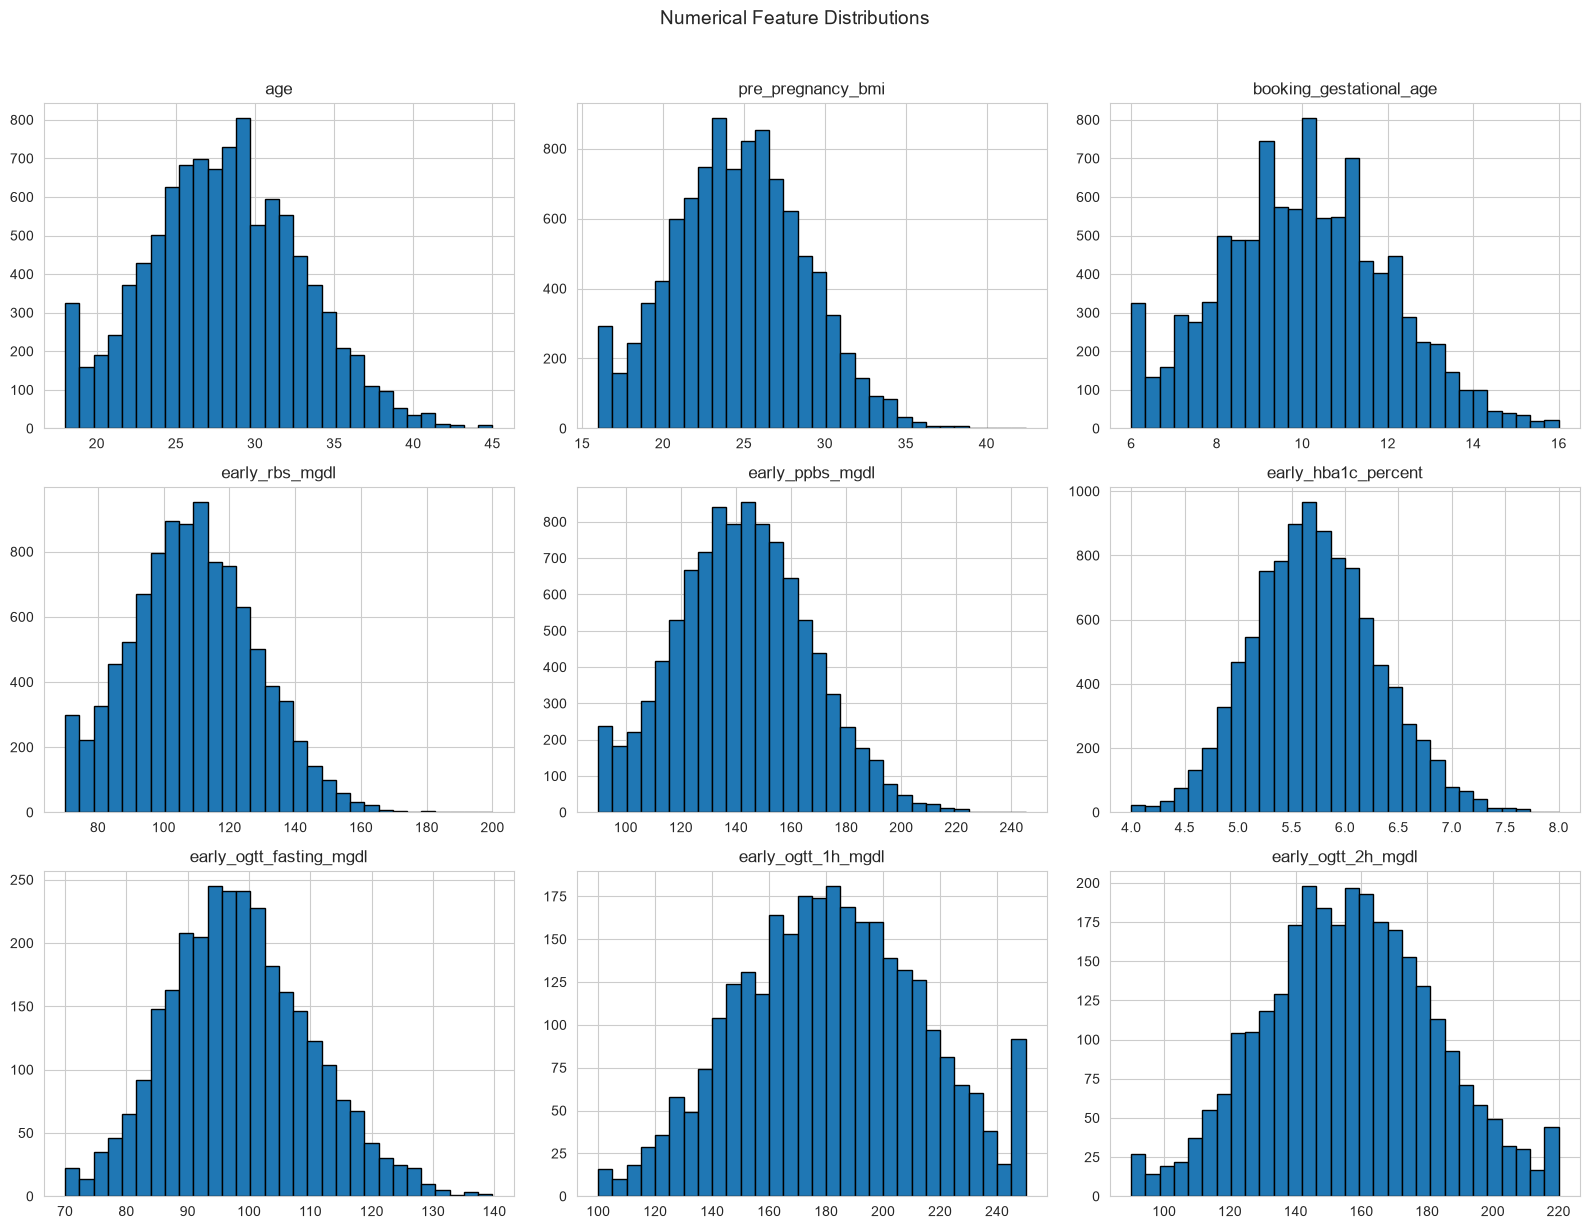

In [63]:
numerical_cols = [
    "age", "pre_pregnancy_bmi", "booking_gestational_age",
    "early_rbs_mgdl", "early_ppbs_mgdl", "early_hba1c_percent",
    "early_ogtt_fasting_mgdl", "early_ogtt_1h_mgdl", "early_ogtt_2h_mgdl"
]

df[numerical_cols].hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Numerical Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 4H. Categorical feature distributions

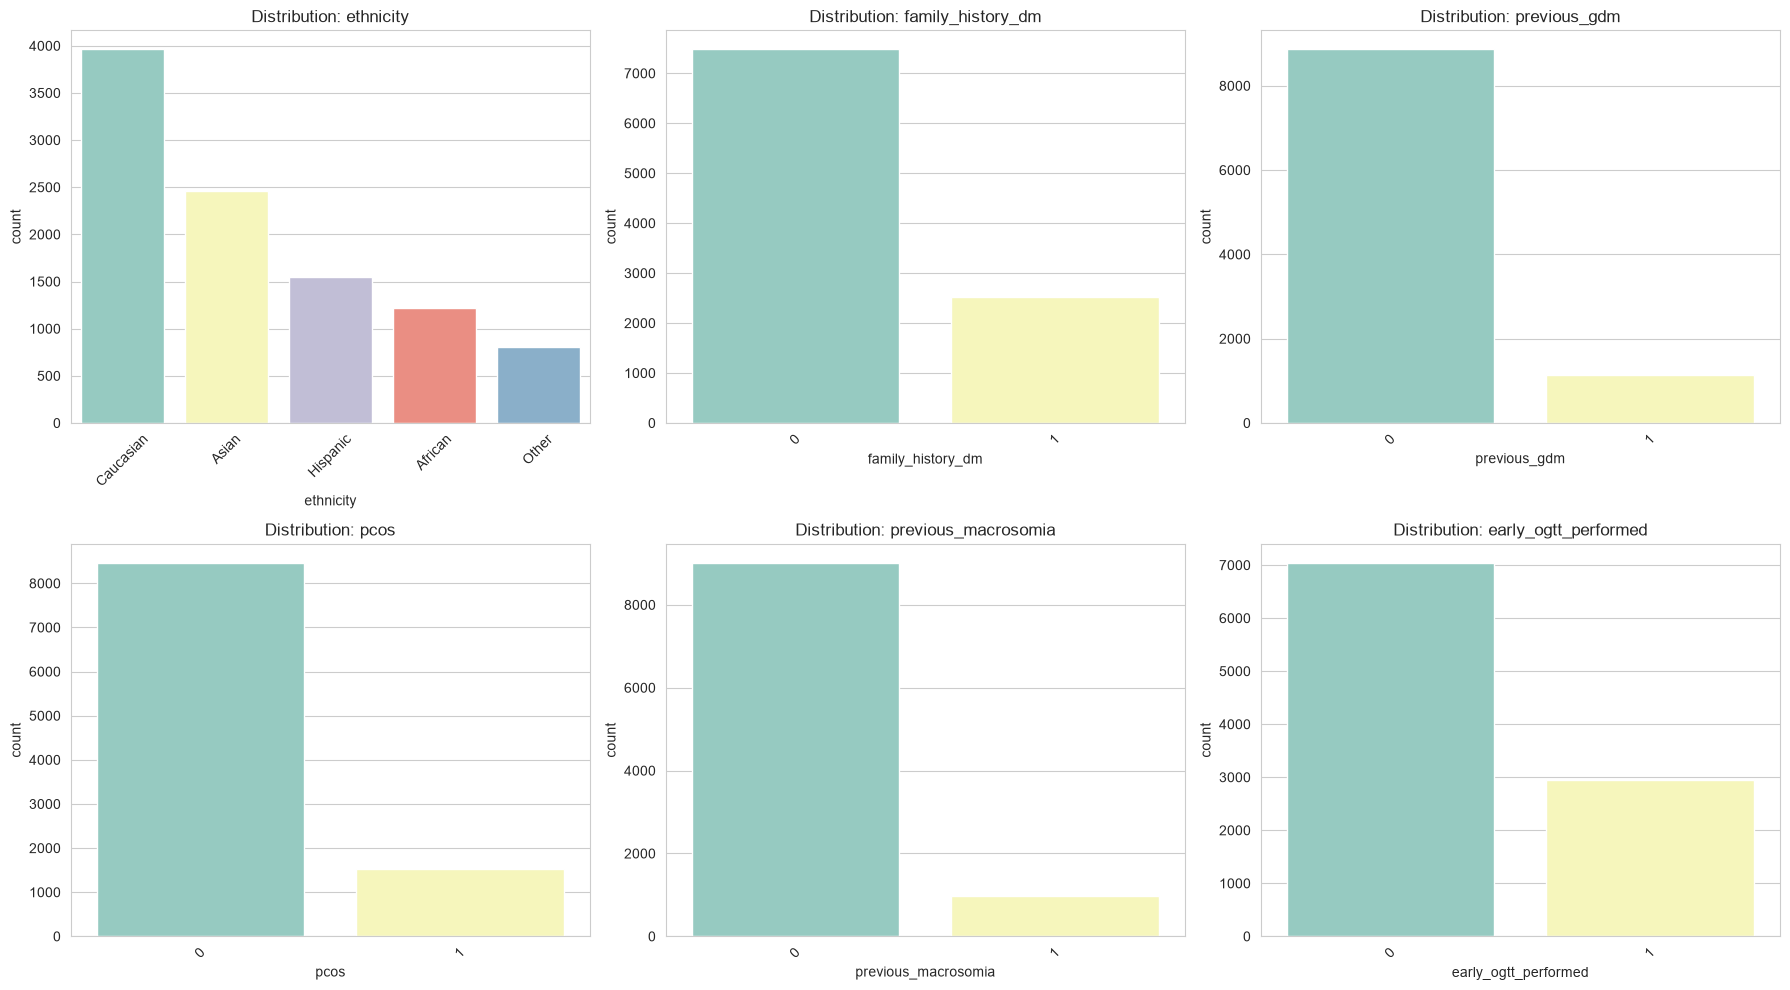

In [64]:
categorical_cols = [
    "ethnicity", "family_history_dm", "previous_gdm", "pcos",
    "previous_macrosomia", "early_ogtt_performed"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, hue=col, palette="Set3", legend=False, ax=axes[i])
    axes[i].set_title(f"Distribution: {col}")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### 4I. Boxplots for important numerical variables

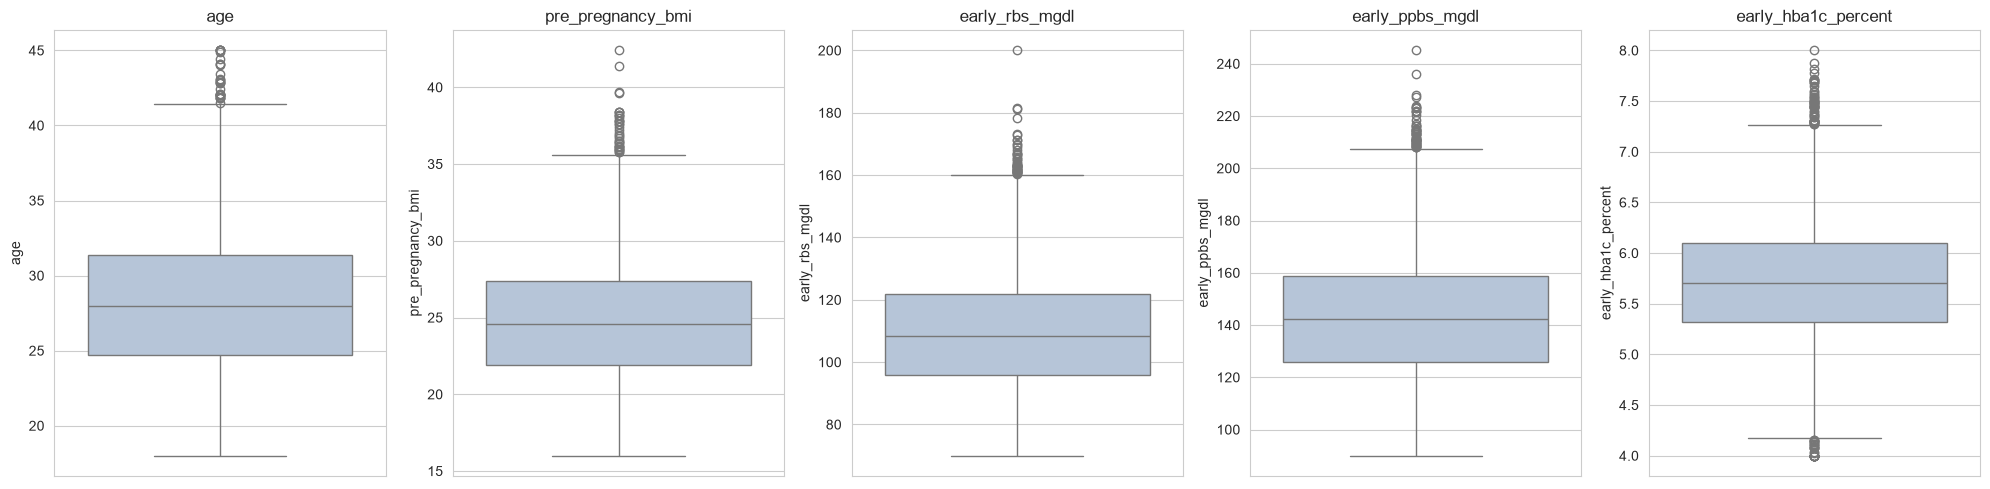

In [65]:
important_numeric = ["age", "pre_pregnancy_bmi", "early_rbs_mgdl", "early_ppbs_mgdl", "early_hba1c_percent"]

fig, axes = plt.subplots(1, len(important_numeric), figsize=(20, 5))
for i, col in enumerate(important_numeric):
    sns.boxplot(y=df[col], ax=axes[i], color="lightsteelblue")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


### 4J. Outlier inspection

Using the IQR method as a simple, transparent way to flag potential outliers (for inspection only — we
are **not** removing rows at this stage; tree-based models are robust to outliers and Logistic Regression
uses scaling, so we let the modeling pipeline handle scale rather than deleting data).


In [66]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = pd.Series(
    {col: iqr_outlier_count(df[col].dropna()) for col in numerical_cols}
).sort_values(ascending=False)

print("Potential outliers per numerical column (IQR method):")
outlier_summary


Potential outliers per numerical column (IQR method):


early_hba1c_percent        83
early_ppbs_mgdl            52
early_rbs_mgdl             44
pre_pregnancy_bmi          36
age                        31
booking_gestational_age    22
early_ogtt_fasting_mgdl    14
early_ogtt_1h_mgdl          0
early_ogtt_2h_mgdl          0
dtype: int64

### 4K. GDM outcome comparisons

Comparing key numerical and binary risk-factor features across GDM outcome groups.


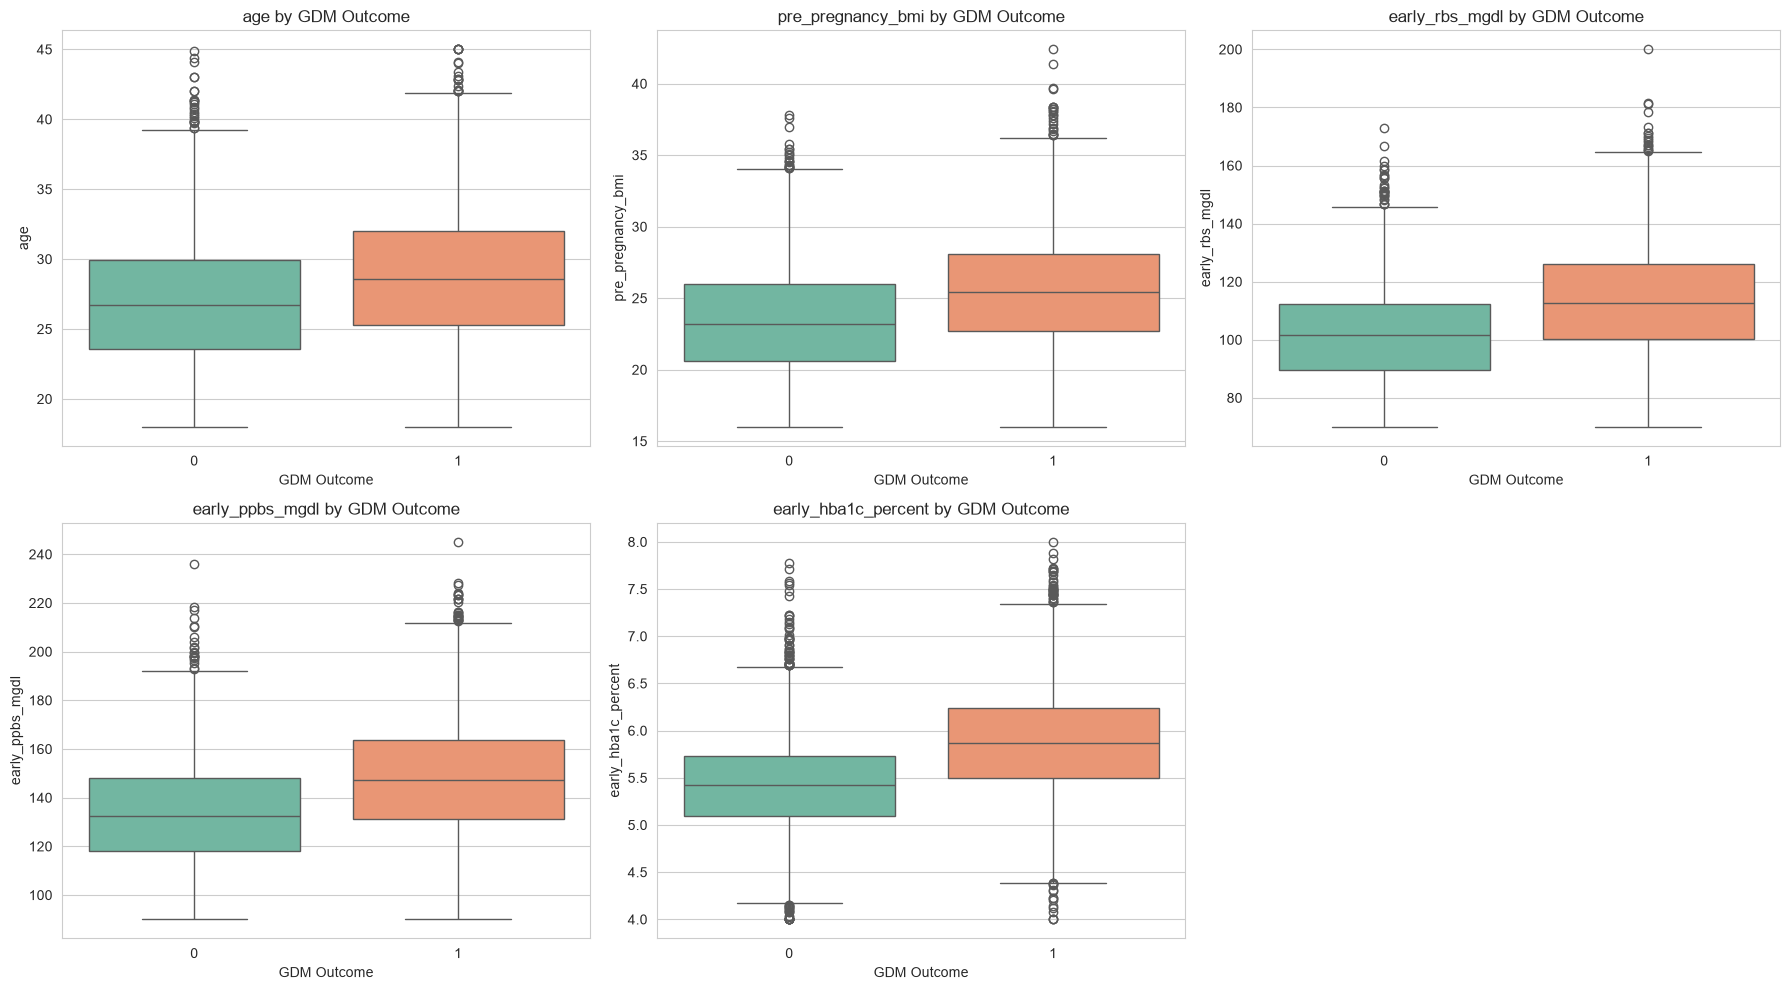

In [67]:
compare_numeric = ["age", "pre_pregnancy_bmi", "early_rbs_mgdl", "early_ppbs_mgdl", "early_hba1c_percent"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(compare_numeric):
    sns.boxplot(x="gdm_outcome", y=col, data=df, hue="gdm_outcome", palette="Set2", legend=False, ax=axes[i])
    axes[i].set_title(f"{col} by GDM Outcome")
    axes[i].set_xlabel("GDM Outcome")

# hide the unused 6th subplot
axes[-1].axis("off")
plt.tight_layout()
plt.show()


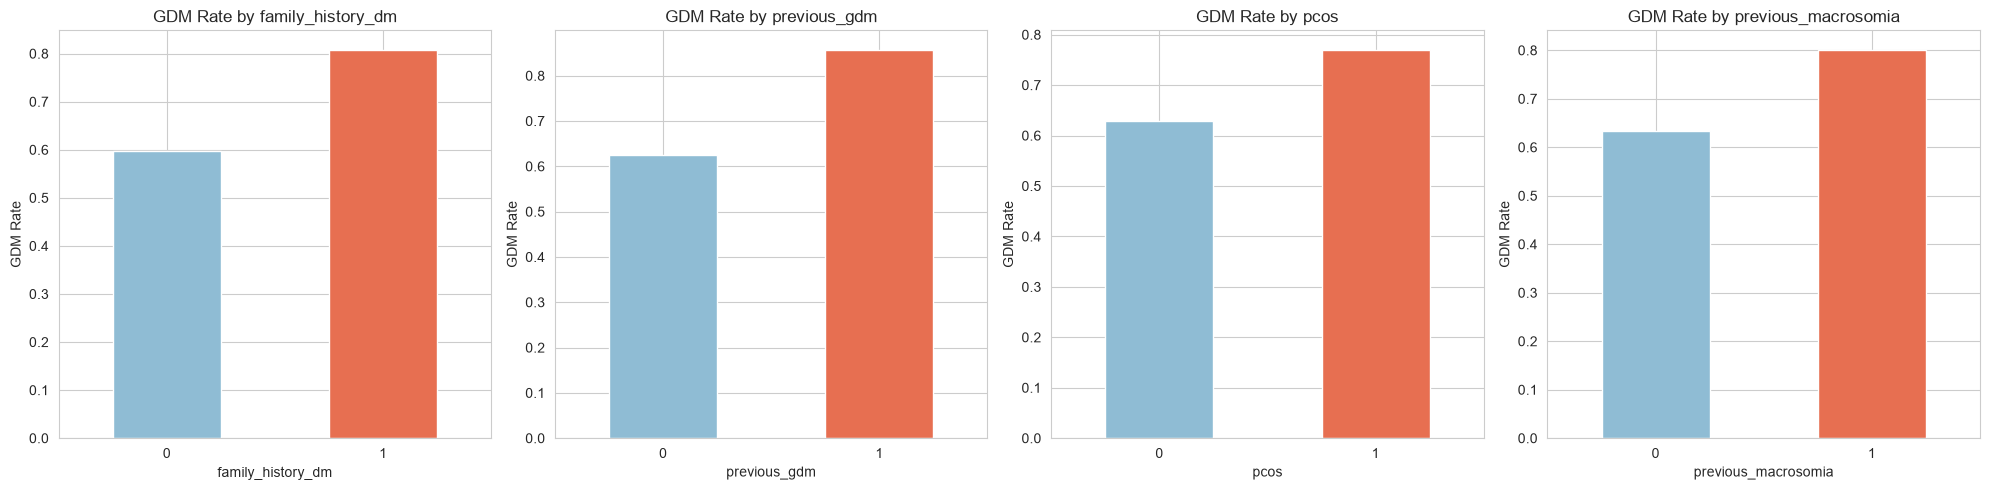

In [68]:
compare_binary = ["family_history_dm", "previous_gdm", "pcos", "previous_macrosomia"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(compare_binary):
    rate_by_group = df.groupby(col)["gdm_outcome"].mean()
    rate_by_group.plot(kind="bar", ax=axes[i], color=["#8fbcd4", "#e76f51"])
    axes[i].set_title(f"GDM Rate by {col}")
    axes[i].set_ylabel("GDM Rate")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### 4L. Correlation heatmap

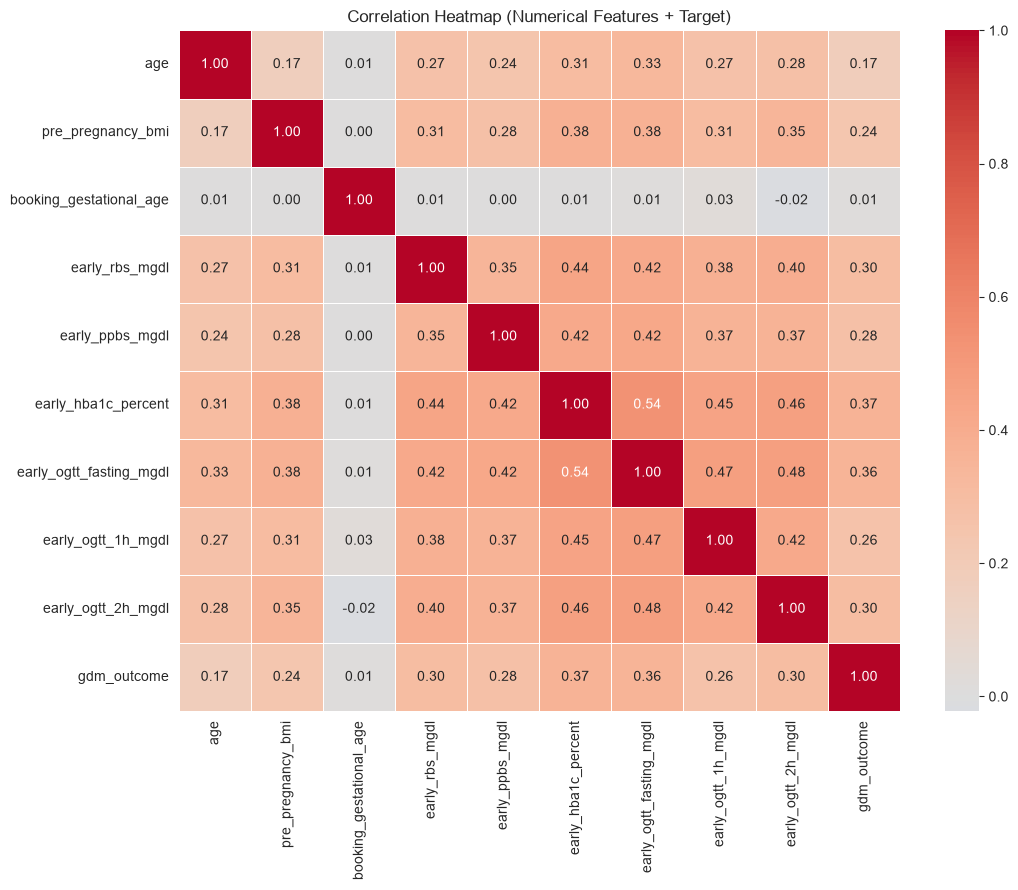

In [69]:
corr_cols = numerical_cols + ["gdm_outcome"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features + Target)")
plt.tight_layout()
plt.show()


### 4M. OGTT missingness analysis

`early_ogtt_fasting_mgdl`, `early_ogtt_1h_mgdl`, and `early_ogtt_2h_mgdl` are missing whenever the early
OGTT test was **not performed** (`early_ogtt_performed == 0`). This is **not random missingness** — it is
a structural pattern tied directly to a recorded flag. Because of this, we:

- **Do not delete** the ~70% of rows where OGTT was not performed (that would discard most of the dataset
  and bias the model).
- **Keep `early_ogtt_performed` as a predictor**, so the model can learn from the fact that a test was or
  wasn't done.
- **Impute** the missing OGTT values (median, fitted on training data only) so the model can still use
  those columns for the ~30% of patients who do have OGTT results.


In [70]:
ogtt_cols = ["early_ogtt_fasting_mgdl", "early_ogtt_1h_mgdl", "early_ogtt_2h_mgdl"]

print("Missing values in OGTT columns:")
print(df[ogtt_cols].isnull().sum())

print("\nValue counts for early_ogtt_performed:")
print(df["early_ogtt_performed"].value_counts())

# Cross-check: confirm missingness lines up with early_ogtt_performed == 0
for col in ogtt_cols:
    mismatch = ((df["early_ogtt_performed"] == 1) & (df[col].isnull())).sum()
    print(f"{col}: rows where OGTT was performed but value is missing = {mismatch}")

print(
    "\nConclusion: OGTT columns are missing precisely when early_ogtt_performed == 0, "
    "i.e., the test was not performed for that patient. This is Missing Not At Random (MNAR) "
    "with respect to a known, recorded cause -- not random data loss."
)


Missing values in OGTT columns:
early_ogtt_fasting_mgdl    7048
early_ogtt_1h_mgdl         7048
early_ogtt_2h_mgdl         7048
dtype: int64

Value counts for early_ogtt_performed:
early_ogtt_performed
0    7048
1    2952
Name: count, dtype: int64
early_ogtt_fasting_mgdl: rows where OGTT was performed but value is missing = 0
early_ogtt_1h_mgdl: rows where OGTT was performed but value is missing = 0
early_ogtt_2h_mgdl: rows where OGTT was performed but value is missing = 0

Conclusion: OGTT columns are missing precisely when early_ogtt_performed == 0, i.e., the test was not performed for that patient. This is Missing Not At Random (MNAR) with respect to a known, recorded cause -- not random data loss.


## 5. EDA Findings — Summary

**Key observations from the EDA above:**

- **Elevated / imbalanced target prevalence:** GDM prevalence in this dataset (~65%) is much higher than
  typical real-world prevalence (usually well under 20%). This is a property of the **synthetic** dataset,
  not a real epidemiological finding, and it affects how we should interpret metrics like accuracy
  (hence the emphasis on precision/recall/F1/ROC-AUC in this notebook).
- **OGTT missingness is structural, not random:** OGTT values are missing exactly when
  `early_ogtt_performed == 0` (~70% of records). We keep these rows and use `early_ogtt_performed` as a
  feature, combined with median imputation for the OGTT values themselves.
- **Feature relationships:** Early glucose markers (`early_rbs_mgdl`, `early_ppbs_mgdl`,
  `early_hba1c_percent`) and known clinical risk factors (`family_history_dm`, `previous_gdm`, `pcos`,
  `previous_macrosomia`) show visible separation between GDM and non-GDM groups in the boxplots/bar
  charts above, consistent with their expected clinical relevance (in a real setting).
- **Outliers:** The IQR check flags a modest number of potential outliers in glucose-related columns;
  these are retained since tree-based models handle them reasonably well and clipping/removing them
  could discard genuine high-risk cases.
- **Synthetic-data limitation:** All findings above describe patterns **within this synthetic dataset
  only**. They should not be interpreted as real clinical or epidemiological conclusions.


## 6. Feature Selection

**Predictors used:**
`age`, `pre_pregnancy_bmi`, `ethnicity`, `family_history_dm`, `previous_gdm`, `pcos`,
`previous_macrosomia`, `booking_gestational_age`, `early_rbs_mgdl`, `early_ppbs_mgdl`,
`early_hba1c_percent`, `early_ogtt_performed`, `early_ogtt_fasting_mgdl`, `early_ogtt_1h_mgdl`,
`early_ogtt_2h_mgdl`

**Excluded:**
- `patient_id` — this is a **unique record identifier** with no predictive/clinical meaning. Including it
  would add pure noise at best, and at worst let a model "memorize" individual rows (a form of leakage /
  overfitting to an arbitrary key).
- `gdm_outcome` — this is the **target variable** and must never be used as an input feature.

Feature selection here is a fixed, domain-driven column list decided **before** looking at the test set,
so there is no leakage from test-set information into feature choice.


In [71]:
TARGET = "gdm_outcome"

FEATURES = [
    "age", "pre_pregnancy_bmi", "ethnicity", "family_history_dm", "previous_gdm", "pcos",
    "previous_macrosomia", "booking_gestational_age", "early_rbs_mgdl", "early_ppbs_mgdl",
    "early_hba1c_percent", "early_ogtt_performed", "early_ogtt_fasting_mgdl",
    "early_ogtt_1h_mgdl", "early_ogtt_2h_mgdl"
]

# Sanity check: make sure nothing excluded slipped in, and all features exist in the dataframe
assert "patient_id" not in FEATURES
assert TARGET not in FEATURES
assert all(col in df.columns for col in FEATURES)

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"Number of predictor columns: {len(FEATURES)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


Number of predictor columns: 15
X shape: (10000, 15), y shape: (10000,)


## 7. Train/Test Split

Split happens **before** any preprocessing is fit, using a stratified 80/20 split on the target so both
sets preserve the class balance. The test set is set aside and **not touched again** until final
evaluation (sections 10-14).


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).round(4))


Train shape: (8000, 15)  Test shape: (2000, 15)

Training set class distribution:
gdm_outcome
1    0.6506
0    0.3494
Name: proportion, dtype: float64

Test set class distribution:
gdm_outcome
1    0.6505
0    0.3495
Name: proportion, dtype: float64


## 8. Preprocessing Pipeline

We build a single `ColumnTransformer` that will be **fit only on `X_train`** (scikit-learn pipelines fit
their preprocessing steps inside `.fit()`, so as long as we always call `.fit()` on training data only,
this constraint is respected automatically for every model below).

- **Numerical features** (including the OGTT columns): median imputation, then scaling. Median imputation
  is used for the OGTT columns specifically because their missingness is tied to `early_ogtt_performed`
  being 0 — we keep those rows and fill a "neutral" typical value rather than dropping ~70% of the data.
  `early_ogtt_performed` itself is included as a separate numeric/binary feature so the model can
  distinguish "OGTT not done" patients from "OGTT done, values imputed" patients.
- **Categorical features**: most-frequent imputation (as a safeguard) + one-hot encoding with
  `handle_unknown="ignore"` so unseen categories at inference time don't break the pipeline.
- Scaling is applied uniformly via the shared `ColumnTransformer`; scaling numerical inputs does not
  hurt tree-based models and is required for Logistic Regression, so one preprocessing pipeline is reused
  across all models for simplicity and consistency.


In [73]:
numeric_features = [
    "age", "pre_pregnancy_bmi", "booking_gestational_age",
    "early_rbs_mgdl", "early_ppbs_mgdl", "early_hba1c_percent",
    "early_ogtt_performed",
    "early_ogtt_fasting_mgdl", "early_ogtt_1h_mgdl", "early_ogtt_2h_mgdl"
]

categorical_features = [
    "ethnicity", "family_history_dm", "previous_gdm", "pcos", "previous_macrosomia"
]

assert set(numeric_features) | set(categorical_features) == set(FEATURES)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created.")
print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)


Preprocessing pipeline created.
Numeric features (10): ['age', 'pre_pregnancy_bmi', 'booking_gestational_age', 'early_rbs_mgdl', 'early_ppbs_mgdl', 'early_hba1c_percent', 'early_ogtt_performed', 'early_ogtt_fasting_mgdl', 'early_ogtt_1h_mgdl', 'early_ogtt_2h_mgdl']
Categorical features (5): ['ethnicity', 'family_history_dm', 'previous_gdm', 'pcos', 'previous_macrosomia']


## 9. Baseline Model (DummyClassifier)

A simple baseline (predicting using class frequencies) gives us a floor to compare real models against.
Because of the elevated class prevalence in this dataset, a naive "always predict the majority class"
model can post a deceptively high **accuracy** — this is exactly why we evaluate with
precision/recall/F1/ROC-AUC instead of accuracy alone.


In [74]:
def evaluate_model(name, y_true, y_pred, y_proba):
    """Compute and print standard classification metrics; returns a results dict."""
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)

    print(f"--- {name} ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {"Model": name, "Precision": precision, "Recall": recall, "F1": f1, "ROC-AUC": roc_auc}


results = []  # collects one dict per model for the comparison table in Section 13


In [75]:
dummy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))
])

dummy_pipeline.fit(X_train, y_train)

y_pred_dummy = dummy_pipeline.predict(X_test)
y_proba_dummy = dummy_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_model("Dummy Baseline", y_test, y_pred_dummy, y_proba_dummy))


--- Dummy Baseline ---
Precision: 0.6500
Recall:    0.6510
F1-score:  0.6505
ROC-AUC:   0.4993

Confusion Matrix:
[[243 456]
 [454 847]]

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.35      0.35       699
           1       0.65      0.65      0.65      1301

    accuracy                           0.55      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.54      0.54      0.54      2000



## 10. Logistic Regression

A linear, interpretable baseline model. `class_weight="balanced"` helps account for the class prevalence
seen in the EDA. The preprocessing pipeline is embedded in the model pipeline, so `.fit()` only ever
touches training data.


In [76]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_model("Logistic Regression", y_test, y_pred_logreg, y_proba_logreg))


--- Logistic Regression ---
Precision: 0.8364
Recall:    0.6718
F1-score:  0.7451
ROC-AUC:   0.7756

Confusion Matrix:
[[528 171]
 [427 874]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.76      0.64       699
           1       0.84      0.67      0.75      1301

    accuracy                           0.70      2000
   macro avg       0.69      0.71      0.69      2000
weighted avg       0.74      0.70      0.71      2000



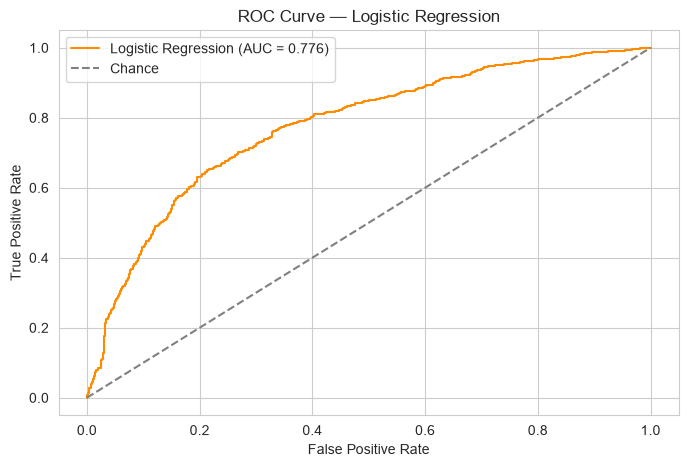

In [77]:
# ROC curve for Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
auc_val = roc_auc_score(y_test, y_proba_logreg)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_val:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()


## 11. Random Forest

In [78]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf))


--- Random Forest ---
Precision: 0.8381
Recall:    0.6764
F1-score:  0.7486
ROC-AUC:   0.7850

Confusion Matrix:
[[529 170]
 [421 880]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.76      0.64       699
           1       0.84      0.68      0.75      1301

    accuracy                           0.70      2000
   macro avg       0.70      0.72      0.70      2000
weighted avg       0.74      0.70      0.71      2000



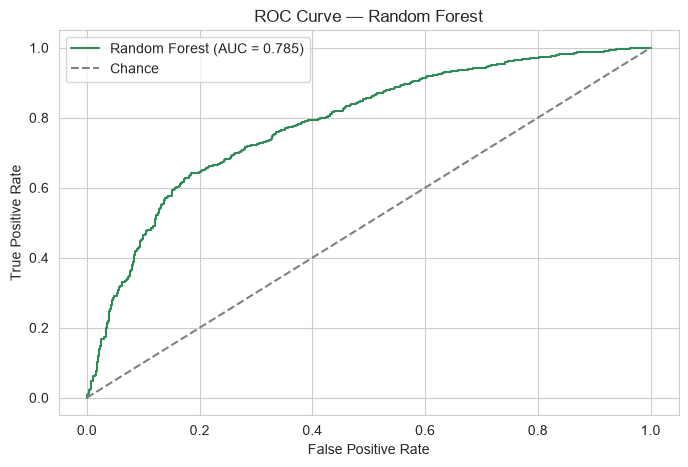

In [79]:
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
auc_val = roc_auc_score(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_val:.3f})", color="seagreen")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.show()


## 12. XGBoost

If XGBoost is not installed, this section is skipped gracefully (a message is printed) rather than
crashing the notebook — install it with `pip install xgboost` and re-run from Section 2 to include it.


In [80]:
if XGBOOST_AVAILABLE:
    # scale_pos_weight approximates class balancing for XGBoost, similar in spirit to class_weight="balanced"
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pos_weight = n_neg / n_pos

    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    xgb_pipeline.fit(X_train, y_train)

    y_pred_xgb = xgb_pipeline.predict(X_test)
    y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

    results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb))
else:
    xgb_pipeline = None
    print("Skipping XGBoost: package not installed. Run `pip install xgboost` and restart the kernel.")


Skipping XGBoost: package not installed. Run `pip install xgboost` and restart the kernel.


In [81]:
if XGBOOST_AVAILABLE:
    fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
    auc_val = roc_auc_score(y_test, y_proba_xgb)

    plt.figure()
    plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_val:.3f})", color="firebrick")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — XGBoost")
    plt.legend()
    plt.show()
else:
    print("Skipping XGBoost ROC curve: package not installed.")


Skipping XGBoost ROC curve: package not installed.


## 13. Model Comparison

Models are compared primarily on **ROC-AUC** and **F1**, while also considering precision and recall —
**not** on accuracy alone, since accuracy can be misleading with the elevated class prevalence in this
synthetic dataset.


In [82]:
comparison_df = pd.DataFrame(results).set_index("Model")
comparison_df = comparison_df.sort_values(by=["ROC-AUC", "F1"], ascending=False)

print("Model Comparison (sorted by ROC-AUC, then F1):")
comparison_df.round(4)


Model Comparison (sorted by ROC-AUC, then F1):


,Precision,Recall,F1,ROC-AUC
Model,,,,
Random Forest,0.8381,0.6764,0.7486,0.7850
Logistic Regression,0.8364,0.6718,0.7451,0.7756
Dummy Baseline,0.6500,0.6510,0.6505,0.4993


In [83]:
# Select the best model based on ROC-AUC first, then F1 as a tiebreaker
candidate_models = {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
}
if XGBOOST_AVAILABLE:
    candidate_models["XGBoost"] = xgb_pipeline

# Exclude the Dummy Baseline from being selected as the "best" model
eligible = comparison_df.drop(index="Dummy Baseline", errors="ignore")
best_model_name = eligible.sort_values(by=["ROC-AUC", "F1"], ascending=False).index[0]
best_model = candidate_models[best_model_name]

print(f"Best model selected: {best_model_name}")
print(eligible.loc[best_model_name].round(4))


Best model selected: Random Forest
Precision    0.8381
Recall       0.6764
F1           0.7486
ROC-AUC      0.7850
Name: Random Forest, dtype: float64


## 14. Confusion Matrices

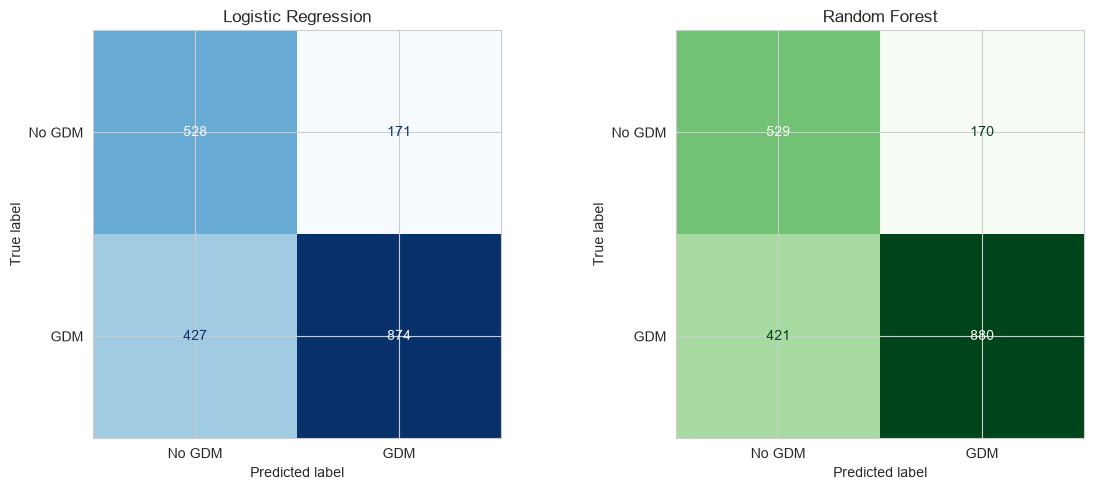

In [84]:
fig, axes = plt.subplots(1, 3 if XGBOOST_AVAILABLE else 2, figsize=(18 if XGBOOST_AVAILABLE else 12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_logreg, display_labels=["No GDM", "GDM"], cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["No GDM", "GDM"], cmap="Greens", ax=axes[1], colorbar=False
)
axes[1].set_title("Random Forest")

if XGBOOST_AVAILABLE:
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_xgb, display_labels=["No GDM", "GDM"], cmap="Reds", ax=axes[2], colorbar=False
    )
    axes[2].set_title("XGBoost")

plt.tight_layout()
plt.show()


## 15. Feature Importance

Because categorical features are one-hot encoded inside the `ColumnTransformer`, we recover the expanded
(post-encoding) feature names directly from the fitted preprocessor before mapping them to importances.


In [85]:
def get_feature_names(fitted_preprocessor):
    """Recover expanded feature names after ColumnTransformer (numeric passthrough + one-hot categorical)."""
    num_names = numeric_features
    cat_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
    return list(num_names) + cat_names


# Use the best tree-based model available for feature importance (Random Forest, or XGBoost if it is the best model)
importance_source_name = best_model_name if best_model_name in ("Random Forest", "XGBoost") else "Random Forest"
importance_pipeline = candidate_models[importance_source_name]

fitted_preprocessor = importance_pipeline.named_steps["preprocessor"]
feature_names = get_feature_names(fitted_preprocessor)
importances = importance_pipeline.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"Feature importance source model: {importance_source_name}")
feature_importance_df.head(20)


Feature importance source model: Random Forest


,feature,importance
0,early_hba1c_percent,0.275155
1,early_rbs_mgdl,0.156904
2,early_ppbs_mgdl,0.131158
3,pre_pregnancy_bmi,0.102211
4,age,0.058641
5,early_ogtt_fasting_mgdl,0.042233
6,family_history_dm_1,0.041135
7,family_history_dm_0,0.033078
8,early_ogtt_2h_mgdl,0.028048
9,booking_gestational_age,0.027232


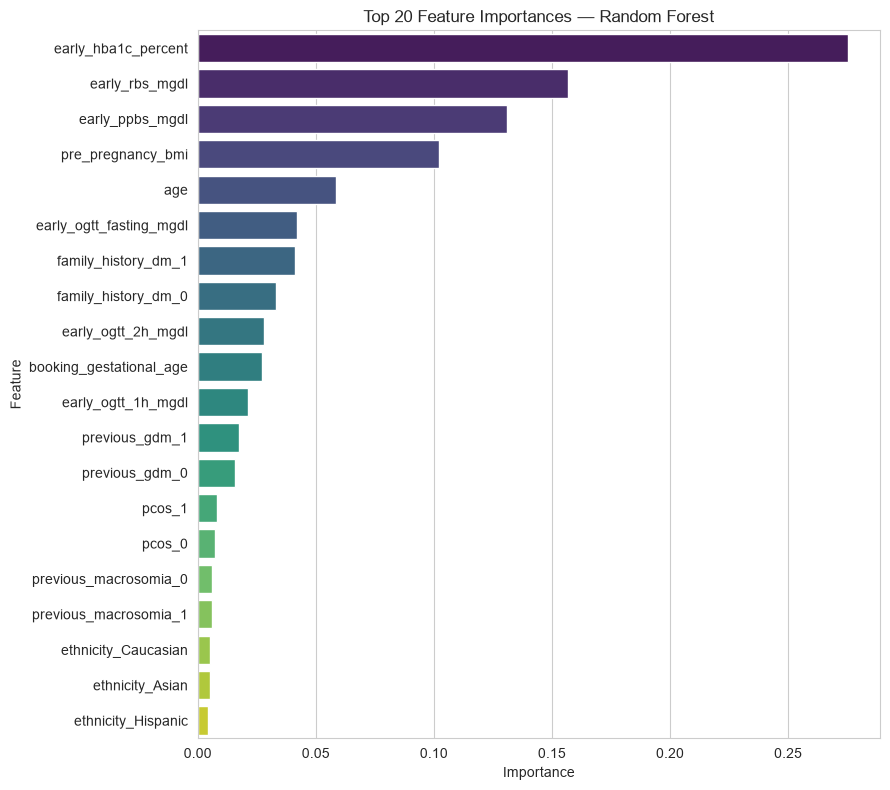

In [86]:
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(9, 8))
sns.barplot(data=top_features, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title(f"Top {top_n} Feature Importances — {importance_source_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 16. SHAP Analysis

SHAP values explain **how much each feature contributed to the model's output for individual predictions**.
This is a measure of **model behavior**, not clinical causation — a feature having a high SHAP contribution
means the model relied on it heavily, which is not the same as that feature *causing* GDM.

If SHAP cannot run (e.g., version incompatibility), the notebook falls back to the feature-importance
results from Section 15 instead of failing.


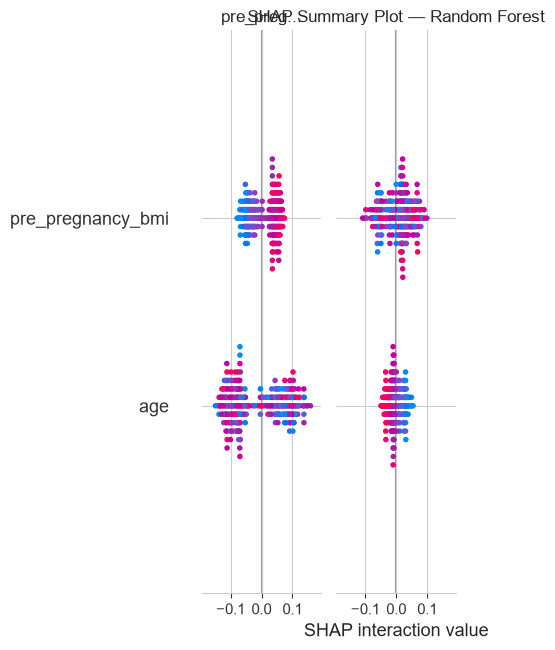

In [87]:
shap_ran_successfully = False

if SHAP_AVAILABLE and importance_source_name in ("Random Forest", "XGBoost"):
    try:
        # Transform a manageable sample of the test set through the fitted preprocessor for SHAP
        sample_size = min(300, X_test.shape[0])
        X_test_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
        X_test_sample_transformed = fitted_preprocessor.transform(X_test_sample)

        # Convert sparse matrix to dense if needed (SHAP tree explainer expects array-like input)
        if hasattr(X_test_sample_transformed, "toarray"):
            X_test_sample_transformed = X_test_sample_transformed.toarray()

        explainer = shap.TreeExplainer(importance_pipeline.named_steps["classifier"])
        shap_values = explainer.shap_values(X_test_sample_transformed)

        # For binary classifiers, shap_values may be a list [class0, class1] or a single array depending on version
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values

        shap.summary_plot(
            shap_values_to_plot,
            X_test_sample_transformed,
            feature_names=feature_names,
            show=False
        )
        plt.title(f"SHAP Summary Plot — {importance_source_name}")
        plt.tight_layout()
        plt.show()

        shap_ran_successfully = True

    except Exception as e:
        print(f"SHAP analysis could not be completed due to an error: {e}")
        print("Falling back to the feature-importance results from Section 15.")

else:
    if not SHAP_AVAILABLE:
        print("SHAP is not installed. Skipping SHAP analysis; showing feature importance instead.")
    else:
        print(f"SHAP TreeExplainer is only used here for tree-based models; "
              f"'{importance_source_name}' is not tree-based. Showing feature importance instead.")

if not shap_ran_successfully:
    print("\n--- Fallback: Top 15 features by model feature importance ---")
    display(feature_importance_df.head(15))


**Note:** SHAP summary plots (when available) show, for each feature, how its values push predictions
toward "GDM" or "No GDM" across the sampled test patients. This reflects **what the model learned from
this synthetic dataset**, not a validated clinical causal relationship.


## 17. Final Model — Save Best Pipeline

We save the **entire fitted pipeline** (preprocessing + model) with `joblib`, so the saved object can take
raw, unprocessed feature data directly (no need to manually re-apply preprocessing at inference time).


In [88]:
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODELS_DIR, "gdm_best_model.joblib")

joblib.dump(best_model, MODEL_PATH)

print(f"Best model ('{best_model_name}') saved to: {MODEL_PATH}")


Best model ('Random Forest') saved to: models\gdm_best_model.joblib


## 18. Sample Prediction

A single synthetic example patient is passed through the saved pipeline to demonstrate inference. This
output is a **model prediction for demonstration purposes only** — see the disclaimer printed below.


In [89]:
# Example synthetic patient using the exact predictor columns (values are illustrative, not real)
sample_patient = pd.DataFrame([{
    "age": 29,
    "pre_pregnancy_bmi": 27.4,
    "ethnicity": X_train["ethnicity"].mode()[0],
    "family_history_dm": 1,
    "previous_gdm": 0,
    "pcos": 0,
    "previous_macrosomia": 0,
    "booking_gestational_age": 10,
    "early_rbs_mgdl": 118.0,
    "early_ppbs_mgdl": 150.0,
    "early_hba1c_percent": 5.6,
    "early_ogtt_performed": 1,
    "early_ogtt_fasting_mgdl": 92.0,
    "early_ogtt_1h_mgdl": 180.0,
    "early_ogtt_2h_mgdl": 155.0,
}])

loaded_model = joblib.load(MODEL_PATH)

pred_class = loaded_model.predict(sample_patient)[0]
pred_proba = loaded_model.predict_proba(sample_patient)[0, 1]

print("=" * 60)
print("MODEL PREDICTION / DECISION-SUPPORT OUTPUT")
print("(NOT a medical diagnosis — synthetic data, prototype model)")
print("=" * 60)
print(f"Predicted class: {pred_class} ({'GDM' if pred_class == 1 else 'No GDM'})")
print(f"Predicted probability of GDM: {pred_proba:.4f}")
print("=" * 60)


MODEL PREDICTION / DECISION-SUPPORT OUTPUT
(NOT a medical diagnosis — synthetic data, prototype model)
Predicted class: 1 (GDM)
Predicted probability of GDM: 0.5117


## 19. Final Conclusion

- **Best model:** the model selected in Section 13 (see `best_model_name` and the comparison table) —
  chosen primarily by ROC-AUC and F1, not accuracy, given the class prevalence seen in the EDA.
- **Test-set metrics:** see the printed evaluation in Sections 9-12 and the comparison table in Section 13
  for the exact precision / recall / F1 / ROC-AUC values achieved on the held-out test set.
- **Important features:** see Section 15's feature-importance ranking (and Section 16's SHAP summary, if
  it ran) — early glucose markers, HbA1c, BMI, and known risk-factor flags are typically among the most
  influential in this synthetic setup.

**Limitations:**
- **Synthetic dataset:** All data, patterns, and metrics in this notebook come from a **synthetic**
  dataset. Nothing here should be interpreted as clinically validated or representative of real patient
  populations.
- **Elevated prevalence:** The ~65% GDM prevalence in this dataset is far higher than real-world
  prevalence, which affects the base rates the model was trained and evaluated on.
- **No temporal / longitudinal information:** The dataset captures early-pregnancy features at a single
  point in time; it does not track how risk evolves across the pregnancy.
- **Missing OGTT testing:** ~70% of records never had an OGTT performed; predictions for those patients
  rely on imputed OGTT values plus the `early_ogtt_performed` flag rather than actual test results.
- **Not a diagnostic system:** This notebook is a **student prototype for a capstone project**. It must
  **not** be used for real clinical decision-making, screening, or diagnosis of GDM or any other condition.
